In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('/content/telecom_fraud_detection_dataset.csv')
df

,call_id,caller_age_days,calls_per_day,call_duration_sec,avg_call_duration_sec,unique_receivers_24h,receiver_block_rate,spam_reports_count,country_code_risk_score,night_call_ratio,sequential_dialing_score,graph_degree,previous_fraud_associations,reputation_score,fraud_label
0,CALL0000001,735,7,449,372.5,9,12.60,4,26.08,15.18,5.19,59,0,88.06,0
1,CALL0000002,63,4,29,26.3,8,52.01,2,41.33,33.81,87.34,57,23,23.50,1
2,CALL0000003,473,24,61,72.8,6,5.24,1,3.12,25.49,32.84,48,0,74.23,0
3,CALL0000004,91,1270,27,37.1,156,36.88,72,50.15,59.64,98.80,351,15,41.23,1
4,CALL0000005,14,1344,69,64.8,135,72.19,3,42.58,85.61,51.92,575,28,17.94,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CALL0009996,1226,852,35,28.0,81,53.91,79,45.66,70.67,97.53,521,18,35.71,1
9996,CALL0009997,2946,13,531,383.9,10,9.24,3,39.16,11.62,17.66,20,1,75.91,0
9997,CALL0009998,24,1438,6,7.2,150,55.84,2,44.36,38.25,62.61,313,25,8.12,1
9998,CALL0009999,33,1024,25,1.0,95,43.23,102,64.42,34.91,39.76,212,18,4.15,1


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   call_id                      10000 non-null  object 
 1   caller_age_days              10000 non-null  int64  
 2   calls_per_day                10000 non-null  int64  
 3   call_duration_sec            10000 non-null  int64  
 4   avg_call_duration_sec        10000 non-null  float64
 5   unique_receivers_24h         10000 non-null  int64  
 6   receiver_block_rate          10000 non-null  float64
 7   spam_reports_count           10000 non-null  int64  
 8   country_code_risk_score      10000 non-null  float64
 9   night_call_ratio             10000 non-null  float64
 10  sequential_dialing_score     10000 non-null  float64
 11  graph_degree                 10000 non-null  int64  
 12  previous_fraud_associations  10000 non-null  int64  
 13  reputation_score 

In [47]:
df.describe()

,caller_age_days,calls_per_day,call_duration_sec,avg_call_duration_sec,unique_receivers_24h,receiver_block_rate,spam_reports_count,country_code_risk_score,night_call_ratio,sequential_dialing_score,graph_degree,previous_fraud_associations,reputation_score,fraud_label
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,773.626600,237.47800,213.367100,210.615840,50.356400,25.088838,18.030500,38.600140,31.241817,33.093151,163.497400,5.043000,63.496163,0.30000
std,728.549185,406.43526,163.899768,177.032595,77.776385,26.525415,32.166751,22.141158,22.258562,27.996123,149.269361,9.117415,26.654174,0.45828
min,0.000000,1.00000,1.000000,1.000000,0.000000,0.090000,0.000000,0.400000,0.180000,0.180000,1.000000,0.000000,0.360000,0.00000
25%,244.000000,6.00000,62.000000,55.800000,7.000000,5.960000,1.000000,20.590000,13.620000,11.310000,61.000000,0.000000,43.080000,0.00000
50%,618.000000,13.00000,198.000000,182.100000,9.000000,11.460000,2.000000,35.620000,24.810000,21.110000,108.000000,0.000000,72.730000,0.00000
75%,1088.000000,317.25000,314.000000,311.125000,73.000000,46.117500,4.000000,54.740000,45.662500,56.102500,220.000000,2.000000,84.882500,1.00000
max,3650.000000,1500.00000,1170.000000,1404.900000,524.000000,98.340000,111.000000,99.220000,98.220000,99.660000,1000.000000,41.000000,99.770000,1.00000


In [48]:
df.columns

Index(['call_id', 'caller_age_days', 'calls_per_day', 'call_duration_sec',
       'avg_call_duration_sec', 'unique_receivers_24h', 'receiver_block_rate',
       'spam_reports_count', 'country_code_risk_score', 'night_call_ratio',
       'sequential_dialing_score', 'graph_degree',
       'previous_fraud_associations', 'reputation_score', 'fraud_label'],
      dtype='object')

In [50]:
df.isna().sum()

,0
call_id,0
caller_age_days,0
calls_per_day,0
call_duration_sec,0
avg_call_duration_sec,0
unique_receivers_24h,0
receiver_block_rate,0
spam_reports_count,0
country_code_risk_score,0
night_call_ratio,0


In [58]:
#measure of central tendency
mean_value=df['caller_age_days'].mean()
print('Mean value:',mean_value)
median_value=df['caller_age_days'].median()
print('Median value:',median_value)

Mean value: 773.6266
Median value: 618.0


In [54]:
a=np.mean(df['caller_age_days'])
a

np.float64(773.6266)

In [65]:
print('spam_reports_count')
mean_value=df['spam_reports_count'].mean()
print('Mean value:',mean_value)
median_value=df['spam_reports_count'].median()
print('Median value:',median_value)
modes=df['spam_reports_count'].mode()
print('Mode:',modes)

spam_reports_count
Mean value: 18.0305
Median value: 2.0
Mode: 0    1
Name: spam_reports_count, dtype: int64


In [67]:

print('unique_receivers_24h\n')
mean_value=df['unique_receivers_24h'].mean()
print('Mean value:',mean_value)

median_value=df['unique_receivers_24h'].median()
print('Median value:',median_value)

modes=df['unique_receivers_24h'].mode()
print('Mode:',modes)

unique_receivers_24h

Mean value: 50.3564
Median value: 9.0
Mode: 0    7
Name: unique_receivers_24h, dtype: int64


In [68]:
print('sequential_dialing_score\n')
mean_value=df['sequential_dialing_score'].mean()
print('Mean value:',mean_value)

median_value=df['sequential_dialing_score'].median()
print('Median value:',median_value)

sequential_dialing_score

Mean value: 33.093151
Median value: 21.11


In [76]:
#measure of deviation
max_val=df['avg_call_duration_sec'].max()
print("Max value:",max_val)
min_val=df['avg_call_duration_sec'].min()
print("Min value:",min_val)

Range=max_val-min_val
print('\nRange:',Range)

Max value: 1404.9
Min value: 1.0

Range: 1403.9


In [77]:
max_val=df['reputation_score'].max()
print("Max value:",max_val)
min_val=df['reputation_score'].min()
print("Min value:",min_val)

Range=max_val-min_val
print('\nRange:',Range)

Max value: 99.77
Min value: 0.36

Range: 99.41


In [81]:
#std.deviation,variance
print("graph_degree")
standard=df['graph_degree'].std()
print("\nstandard deviation:",standard)
variance=df['graph_degree'].var()
print("\nvariance:",variance)


graph_degree

standard deviation: 149.26936098025175

variance: 22281.342127452703


In [82]:
print("previous_fraud_associations")
standard=df['previous_fraud_associations'].std()
print("\nstandard deviation:",standard)
variance=df['previous_fraud_associations'].var()
print("\nvariance:",variance)


previous_fraud_associations

standard deviation: 9.11741540823826

variance: 83.12726372638043


In [93]:
#IQR(Interquartile Range)
Q1 = df['night_call_ratio'].quantile(0.25)
Q3 = df['night_call_ratio'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 13.62
Q3: 45.662499999999994
IQR: 32.0425


In [94]:
Q1 = df['unique_receivers_24h'].quantile(0.25)
Q3 = df['unique_receivers_24h'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 7.0
Q3: 73.0
IQR: 66.0


In [97]:
Q2 = df['unique_receivers_24h'].quantile(0.50)
print("Q2:", Q2)

Q2: 9.0


<Axes: xlabel='night_call_ratio', ylabel='count'>

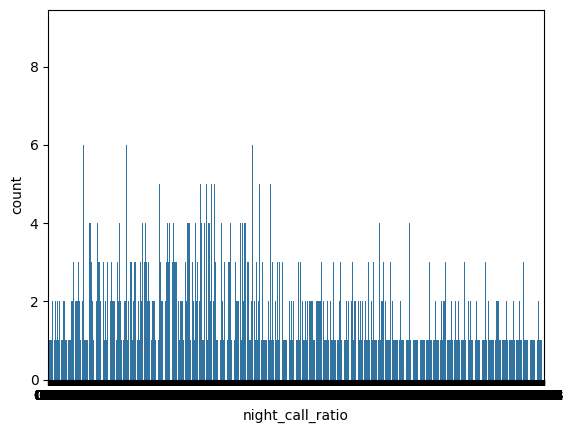

In [99]:
#measures of frequency
sns.countplot(data=df,x='night_call_ratio',orient="Horizontal")

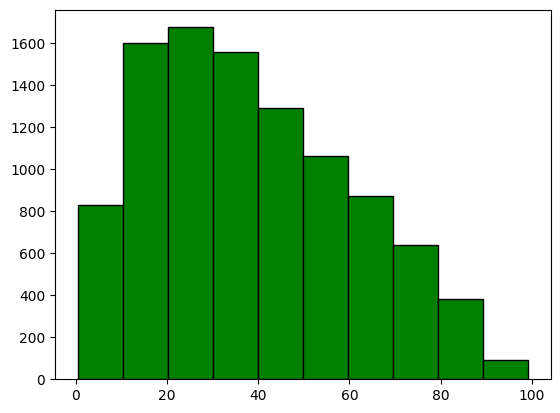

In [100]:
plt.hist(df["country_code_risk_score"],color='green',edgecolor='black')
plt.show()

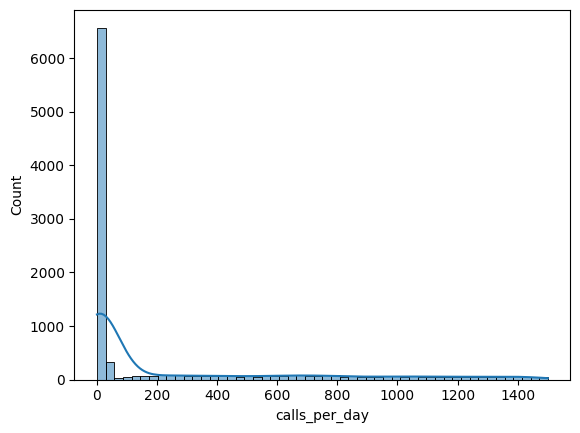

In [101]:
sns.histplot(df["calls_per_day"],kde=True)
plt.show()

<Axes: xlabel='unique_receivers_24h'>

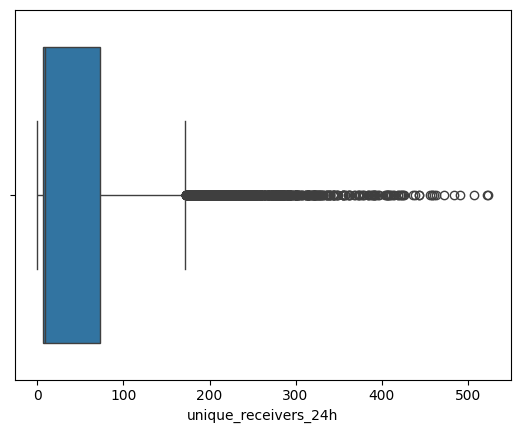

In [102]:
sns.boxplot(x='unique_receivers_24h',data=df)

<Axes: xlabel='calls_per_day', ylabel='avg_call_duration_sec'>

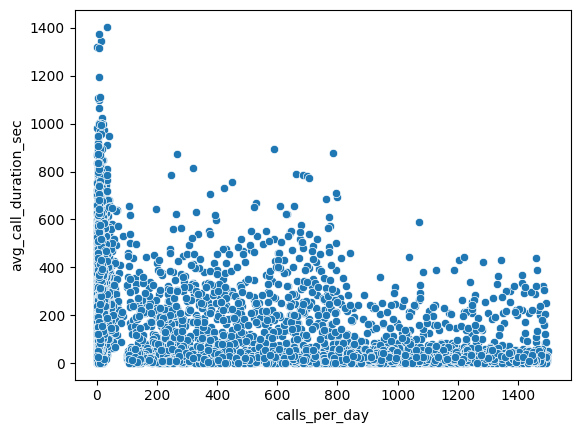

In [103]:
sns.scatterplot(data=df,x='calls_per_day',y='avg_call_duration_sec',legend='auto')

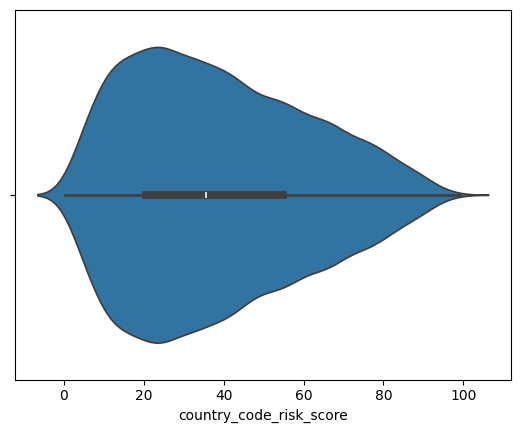

In [105]:
sns.violinplot(data=df, x='country_code_risk_score')
plt.show()

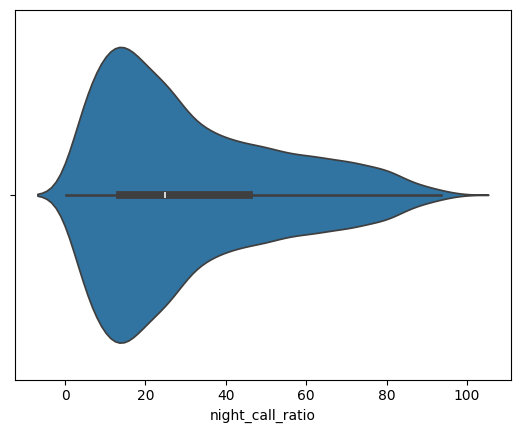

In [111]:
sns.violinplot(data=df, x='night_call_ratio')
plt.show()

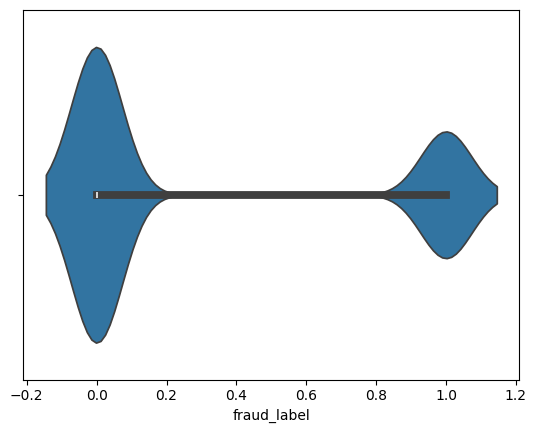

In [122]:

sns.violinplot(data=df, x='fraud_label')
plt.show( )

In [116]:
#measures of distribution
print("skewness of (sequential_dialing_score)")
df["sequential_dialing_score"].head(15).skew()

skewness of (sequential_dialing_score)


np.float64(0.6684363044273502)

In [117]:
print("kurtosis of (sequential_dialing_score)")
df["sequential_dialing_score"].head(15).kurtosis()

kurtosis of (sequential_dialing_score)


np.float64(-1.2468866957709182)

In [119]:
print("skewness of (sequential_dialing_score)")
df["sequential_dialing_score"].skew()

skewness of (sequential_dialing_score)


np.float64(0.8662955781945301)

In [120]:
print("kurtosis of (sequential_dialing_score)")
df["sequential_dialing_score"].kurtosis()

kurtosis of (sequential_dialing_score)


np.float64(-0.6676802241867832)

In [124]:
print("skewness of (previous_fraud_associations)")
sk=df["previous_fraud_associations"].skew()
print("Skewness:",sk)
print("\nkurtosis of (previous_fraud_associations)")
kurt=df["previous_fraud_associations"].kurtosis()
print("Kurtosis:",kurt)

skewness of (previous_fraud_associations)
Skewness: 1.565750739936458

kurtosis of (previous_fraud_associations)
Kurtosis: 0.8181368434819314
